### Get the dataloader

In [8]:
from dataloader import load_ddi_data, create_folds, get_dataloaders

# Load embeddings and pairs for each knowledge level
levels = ["low_level", "mid_level", "deep_level"]
pos_path = "../datasets/DDI_filtered.csv"
neg_path = "../datasets/negatives_filtered.csv"
emb_dir = "../datasets"

levels = ["low_level", "mid_level", "deep_level"]

data = {}
for level in levels:
    X, y, pairs = load_ddi_data(level, pos_path, neg_path, emb_dir)
    folds = create_folds(X, y, n_splits=5)
    data[level] = {"X": X, "y": y, "folds": folds, "pairs": pairs}


[low_level] Drug coverage check:
   Positives covered: 363,321
   Negatives covered: 4,791
   ⚖️  Sampled 4,791 positives to match 4,791 negatives (Δ=0).
[low_level] Final dataset: 9,582 pairs (4791 pos, 4791 neg)
→ Feature shape: (9582, 256)

[mid_level] Drug coverage check:
   Positives covered: 453,524
   Negatives covered: 5,391
   ⚖️  Sampled 5,391 positives to match 5,391 negatives (Δ=0).
[mid_level] Final dataset: 10,782 pairs (5391 pos, 5391 neg)
→ Feature shape: (10782, 256)

[deep_level] Drug coverage check:
   Positives covered: 440,719
   Negatives covered: 5,388
   ⚖️  Sampled 5,388 positives to match 5,388 negatives (Δ=0).
[deep_level] Final dataset: 10,776 pairs (5388 pos, 5388 neg)
→ Feature shape: (10776, 256)


### Train & 5-Fold CV

In [9]:
import numpy as np
import pandas as pd
import torch
from MLP import MLP_DDI
from utils import train_one_fold, evaluate_by_pair_bins, PAIR_BINS, PAIR_BIN_NAMES

device = "cuda" if torch.cuda.is_available() else "cpu"

# map drugs to categories
drug_info = pd.read_csv("../drugbank/extended_drug_info.csv")[["drugbank_id","knowledge_category"]].drop_duplicates()
drug_to_cat = drug_info.set_index("drugbank_id")["knowledge_category"].to_dict()

all_summaries = []
res_long = []   # ✅ collect all per-fold results here

for feature_level in ["low_level", "mid_level", "deep_level"]:
    print(f"\nTraining model for {feature_level}")
    X = data[feature_level]["X"]
    y = data[feature_level]["y"]
    folds = data[feature_level]["folds"]
    pairs = data[feature_level]["pairs"]

    # per-bin list of fold metric dicts
    per_bin = {name: [] for name in [PAIR_BIN_NAMES[k] for k in PAIR_BINS]}

    for fold_idx in range(5):
        print(f"\nFold {fold_idx+1}/5")
        train_loader, test_loader, _, _ = get_dataloaders(X, y, folds, fold_idx, batch_size=128)
        train_idx, test_idx = folds[fold_idx]

        model = MLP_DDI(input_dim=X.shape[1], hidden_dims=(256,128,64), dropout=0.3)
        model, history = train_one_fold(model, train_loader, test_loader,
                                        n_epochs=100, patience=10, lr=1e-3, device=device)

        # Evaluate on test fold by 6 pair bins
        fold_pairs = pairs.iloc[test_idx][["drug1","drug2","label"]]
        fold_res = evaluate_by_pair_bins(model, test_loader, fold_pairs, drug_to_cat, device=device, min_samples=30)

        # ✅ Add detailed per-fold rows
        for bin_name, metrics_dict in fold_res.items():
            row = {"feature_set": feature_level, "pair_bin": bin_name, "fold": fold_idx}
            row.update(metrics_dict)  # includes accuracy, auc, etc.
            res_long.append(row)

        # ✅ Accumulate metrics for per-bin mean/std
        for bin_name, m in fold_res.items():
            per_bin[bin_name].append(m)

    # Aggregate per-feature-level (mean ± std)
    rows = []
    for bin_name, lst in per_bin.items():
        if not lst:
            continue
        row = {
            "feature_set": feature_level,
            "pair_bin": bin_name,
            "n_samples_mean": np.mean([d["n_samples"] for d in lst]),
        }
        for met in ["accuracy","precision","recall","f1","auc"]:
            vals = [d[met] for d in lst if not np.isnan(d[met])]
            if len(vals) == 0:
                row[met] = np.nan
                row[f"{met}_std"] = np.nan
            else:
                row[met] = float(np.mean(vals))
                row[f"{met}_std"] = float(np.std(vals))
        rows.append(row)

    summary_df = pd.DataFrame(rows)
    all_summaries.append(summary_df)

# ✅ Save results
res_summary = pd.concat(all_summaries, ignore_index=True)
res_long = pd.DataFrame(res_long)

res_summary.to_csv("results_pair_bins_mean_std.csv", index=False)
res_long.to_csv("results_pair_bins_per_fold.csv", index=False)

print("\n📊 Saved:")
print(" - Aggregated results → results_pair_bins_mean_std.csv")
print(" - Per-fold metrics → results_pair_bins_per_fold.csv")


Training model for low_level

Fold 1/5
Epoch 01/100 | Train Loss: 0.5293 | Val Loss: 0.4080 | Val AUC: 0.8974
Epoch 02/100 | Train Loss: 0.3878 | Val Loss: 0.3727 | Val AUC: 0.9161
Epoch 03/100 | Train Loss: 0.3392 | Val Loss: 0.3542 | Val AUC: 0.9219
Epoch 04/100 | Train Loss: 0.3090 | Val Loss: 0.3312 | Val AUC: 0.9332
Epoch 05/100 | Train Loss: 0.2782 | Val Loss: 0.3229 | Val AUC: 0.9384
Epoch 06/100 | Train Loss: 0.2536 | Val Loss: 0.3261 | Val AUC: 0.9374
Epoch 07/100 | Train Loss: 0.2427 | Val Loss: 0.3163 | Val AUC: 0.9407
Epoch 08/100 | Train Loss: 0.2202 | Val Loss: 0.3158 | Val AUC: 0.9442
Epoch 09/100 | Train Loss: 0.2208 | Val Loss: 0.3231 | Val AUC: 0.9429
Epoch 10/100 | Train Loss: 0.1998 | Val Loss: 0.3098 | Val AUC: 0.9461
Epoch 11/100 | Train Loss: 0.1892 | Val Loss: 0.3223 | Val AUC: 0.9444
Epoch 12/100 | Train Loss: 0.1761 | Val Loss: 0.3183 | Val AUC: 0.9469
Epoch 13/100 | Train Loss: 0.1726 | Val Loss: 0.3362 | Val AUC: 0.9440
Epoch 14/100 | Train Loss: 0.1698 | V

### Performance Results

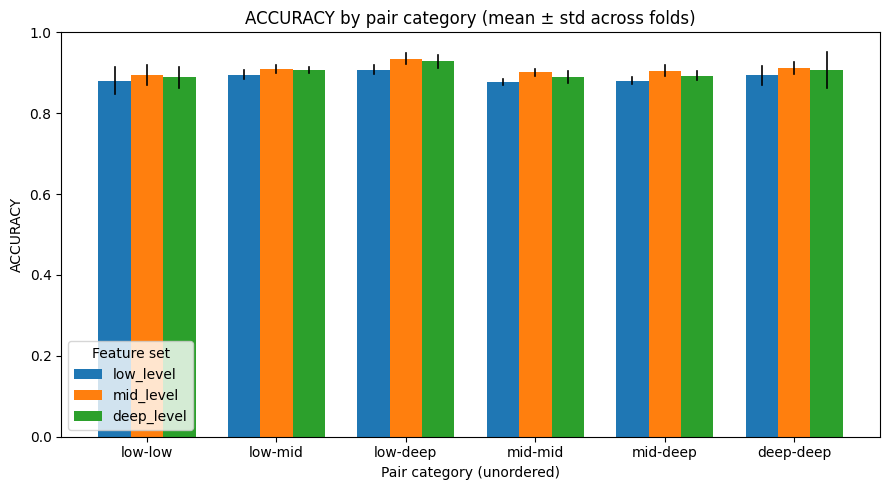

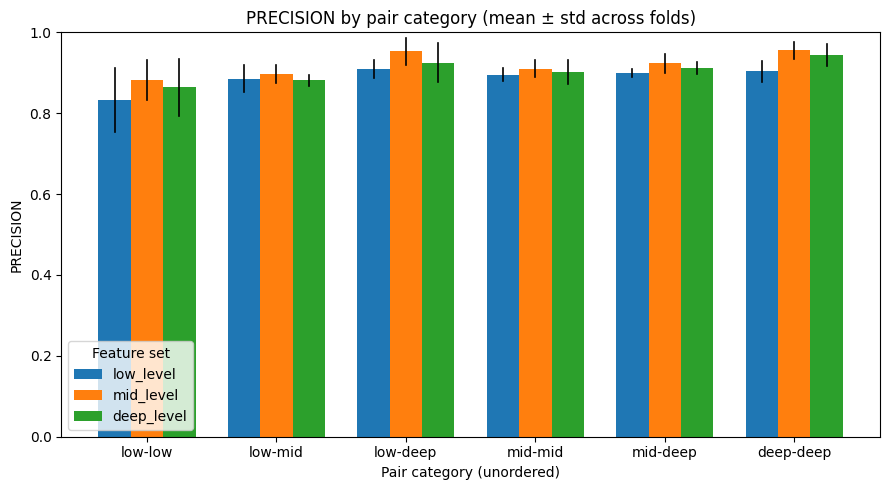

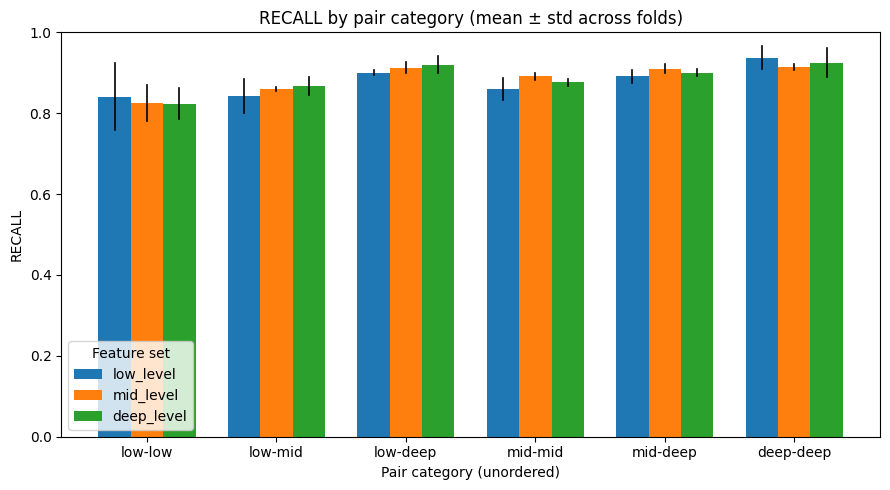

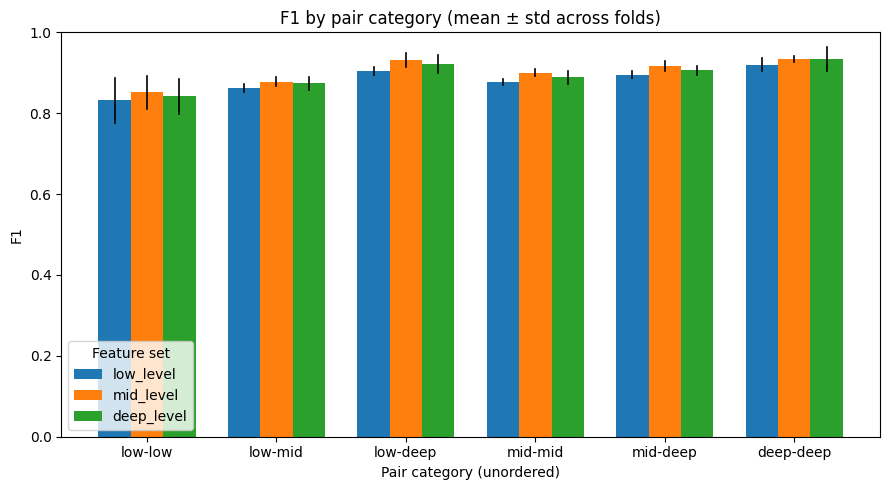

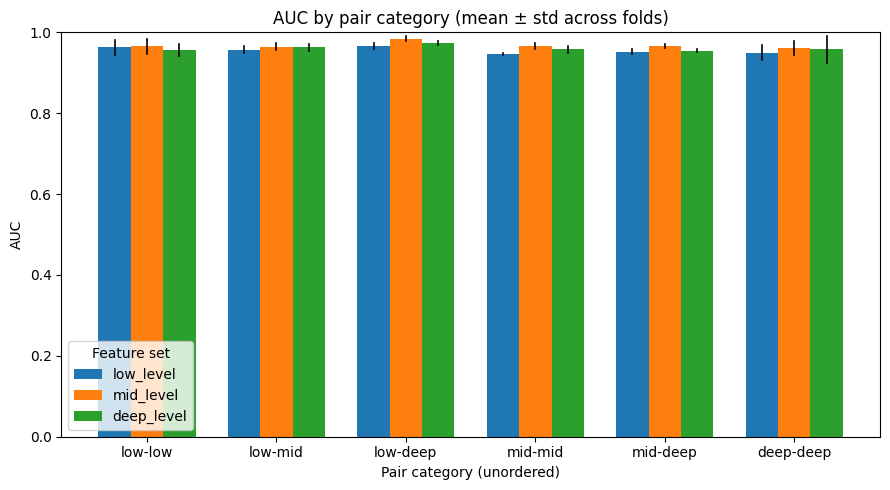

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

res = pd.read_csv("results_pair_bins_mean_std.csv")

# Fix pair_bin sort order
bin_order = ["low-low","low-mid","low-deep","mid-mid","mid-deep","deep-deep"]
feat_order = ["low_level","mid_level","deep_level"]

metrics = ["accuracy","precision","recall","f1","auc"]

for met in metrics:
    plt.figure(figsize=(9,5))
    # bars by pair_bin grouped by feature_set
    width = 0.25
    x = np.arange(len(bin_order))

    for i, feat in enumerate(feat_order):
        sub = res[(res["feature_set"] == feat)].set_index("pair_bin").reindex(bin_order)
        means = sub[met].values
        stds  = sub[f"{met}_std"].values

        # bar positions shifted per feature_set
        pos = x + (i-1)*width
        bars = plt.bar(pos, means, width=width, label=feat)

        # draw std “tips” (small vertical line at bar tip)
        for (px, m, s) in zip(pos, means, stds):
            if pd.isna(m) or pd.isna(s):
                continue
            plt.plot([px, px], [m - s, m + s], color="black", linewidth=1.2)

    plt.xticks(x, bin_order, rotation=0)
    plt.ylim(0, 1.0)
    plt.ylabel(met.upper())
    plt.xlabel("Pair category (unordered)")
    plt.title(f"{met.upper()} by pair category (mean ± std across folds)")
    plt.legend(title="Feature set")
    plt.tight_layout()
    plt.show()

In [11]:
from scipy.stats import ttest_rel

res_long = pd.read_csv("results_pair_bins_per_fold.csv")

for metric in ["auc", "accuracy", "f1"]:
    subset = res_long[res_long["pair_bin"] == "low-low"]

    vals_low  = subset[subset.feature_set == "low_level"][metric].values
    vals_deep = subset[subset.feature_set == "deep_level"][metric].values

    if len(vals_low) == len(vals_deep) and len(vals_low) > 1:
        t, p = ttest_rel(vals_low, vals_deep)
        print(f"{metric}: t={t:.3f}, p={p:.4f}")
    else:
        print(f"{metric}: insufficient folds ({len(vals_low)} vs {len(vals_deep)})")

auc: t=0.629, p=0.5634
accuracy: t=-0.541, p=0.6171
f1: t=-0.392, p=0.7151


In [12]:
from scipy.stats import friedmanchisquare

subset = res_long[res_long["pair_bin"] == "low-low"]
auc_low  = subset[subset.feature_set == "low_level"]["auc"].values
auc_mid  = subset[subset.feature_set == "mid_level"]["auc"].values
auc_deep = subset[subset.feature_set == "deep_level"]["auc"].values

stat, p = friedmanchisquare(auc_low, auc_mid, auc_deep)
print(f"Friedman test: χ²={stat:.3f}, p={p:.4f}")

Friedman test: χ²=1.200, p=0.5488
